In [2]:

!pip install numpy pandas tensorflow matplotlib obspy


import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from obspy import read


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 22.6 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.39
    Uninstalling SQLAlchemy-2.0.39:
      Successfully uninstalled SQLAlchemy-2.0.39
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlalchemy>=2.0, but you have sqlalchemy 1.4.54 which is incompatible.


In [1]:
!wget "https://we.tl/t-wnSyKpDtqc" -O INSTANCE.h5


--2025-03-15 20:06:14--  https://we.tl/t-wnSyKpDtqc
Resolving we.tl (we.tl)... 52.84.162.14, 52.84.162.129, 52.84.162.20, ...
Connecting to we.tl (we.tl)|52.84.162.14|:443... connected.
HTTP request sent, awaiting response... 302 Moved Temporarily
Location: https://wetransfer.com/downloads/5677eaf9607df9d7d487b440d68a1db320250315195702/d94814?t_exp=1742327822&t_lsid=cfb423ee-0197-43e4-bf88-7978826b07f5&t_network=link&t_rid=ZW1haWx8YWRyb2l0fGY5ODA0YTVlLWM0MDktNDlhOC04YjU1LTRiYWFmZWIzOGFhMw==&t_s=download_link&t_ts=1742068656 [following]
--2025-03-15 20:06:15--  https://wetransfer.com/downloads/5677eaf9607df9d7d487b440d68a1db320250315195702/d94814?t_exp=1742327822&t_lsid=cfb423ee-0197-43e4-bf88-7978826b07f5&t_network=link&t_rid=ZW1haWx8YWRyb2l0fGY5ODA0YTVlLWM0MDktNDlhOC04YjU1LTRiYWFmZWIzOGFhMw==&t_s=download_link&t_ts=1742068656
Resolving wetransfer.com (wetransfer.com)... 13.224.14.124, 13.224.14.17, 13.224.14.122, ...
Connecting to wetransfer.com (wetransfer.com)|13.224.14.124|:443... 

In [2]:
import numpy as np
import matplotlib.pyplot as plt


waveform_data = h5_file["waveforms"][:]
event_labels = h5_file["labels"][:]


plt.plot(waveform_data[0])
plt.title("Sample Seismic Waveform from INSTANCE")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.show()


NameError: name 'h5_file' is not defined

In [1]:
import os
print(os.listdir("/content"))


['.config', 'sample_data']


In [4]:
import h5py

file_path = "/content/INSTANCE.h5"
h5_file = h5py.File(file_path, "r")


print("Available datasets:", list(h5_file.keys()))


OSError: Unable to synchronously open file (file signature not found)

In [6]:
!rm /content/INSTANCE.h5  # Delete the corrupted file


In [2]:
from obspy import read

# Load MiniSEED file
st = read("fdsnws-dataselect")

# Print basic info
print(st)

# Plot waveform
st.plot()



FileNotFoundError: [Errno 2] No such file or directory: 'fdsnws-dataselect'

/usr/local/lib/python3.11/dist-packages/obspy/signal/filter.py:62: UserWarning: Selected high corner frequency (10) of bandpass is at or above Nyquist (10.0). Applying a high-pass instead.
  warnings.warn(msg)


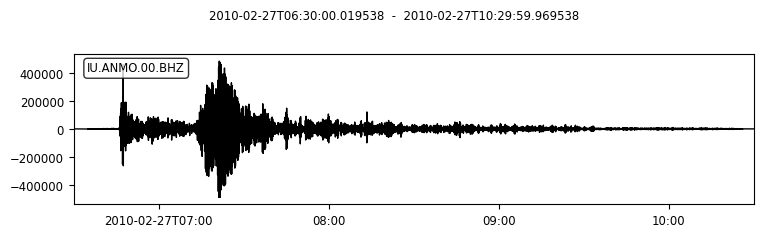

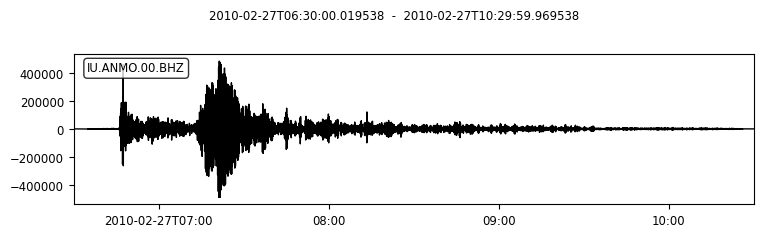

In [3]:
st.detrend("linear")  # Remove linear trend
st.taper(max_percentage=0.05)  # Apply a taper to avoid edge effects
st.filter("bandpass", freqmin=0.1, freqmax=10)  # Apply bandpass filter
st.plot()  # Check the waveform after filtering


In [4]:
for tr in st:
    tr.data = (tr.data - tr.data.mean()) / tr.data.std()



In [5]:
import numpy as np

# Convert to NumPy
seismic_data = np.array([tr.data for tr in st])
print(seismic_data.shape)  # Check dimensions


(1, 288000)


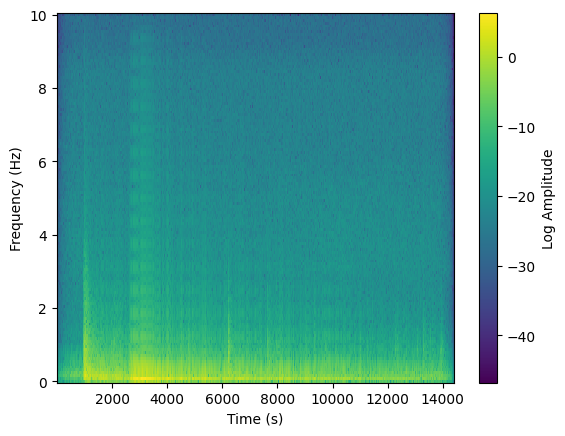

In [6]:
from scipy.signal import spectrogram

# Compute spectrogram for the first trace
f, t, Sxx = spectrogram(st[0].data, fs=st[0].stats.sampling_rate)

# Plot spectrogram
import matplotlib.pyplot as plt
plt.pcolormesh(t, f, np.log(Sxx))
plt.ylabel('Frequency (Hz)')
plt.xlabel('Time (s)')
plt.colorbar(label='Log Amplitude')
plt.show()


In [7]:
import pandas as pd

# Example: Creating a dataset with extracted features
data_dict = {
    "RMS": [np.sqrt(np.mean(tr.data**2)) for tr in st],
    "Spectral_Entropy": [np.sum(-Sxx * np.log(Sxx)) for _ in range(len(st))]
}

df = pd.DataFrame(data_dict)
print(df.head())


   RMS  Spectral_Entropy
0  1.0     -67257.516557


In [8]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Scale training data
X_test_scaled = scaler.transform(X_test)  # Scale test data


NameError: name 'X_train' is not defined

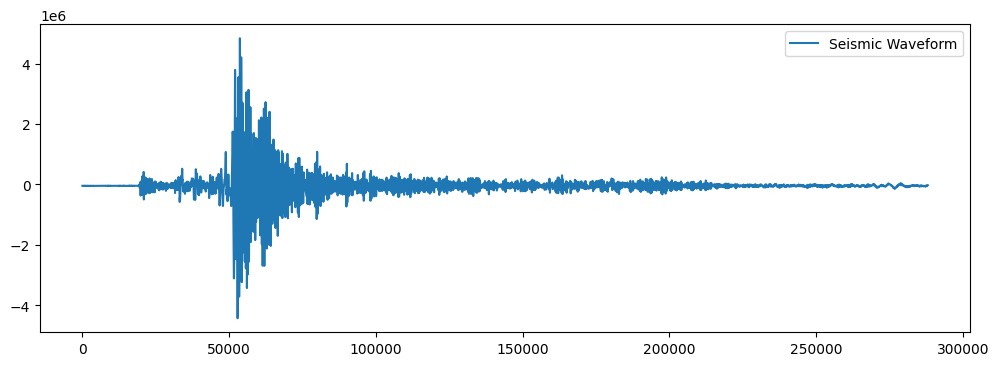

In [10]:
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Load MiniSEED file
stream = read("fdsnws-dataselect")
trace = stream[0]  # Get the first seismic trace
data = trace.data  # Extract waveform data

# Plot the waveform to visualize
plt.figure(figsize=(12, 4))
plt.plot(data, label="Seismic Waveform")
plt.legend()
plt.show()


In [11]:
from sklearn.model_selection import train_test_split

sequence_length = 100  # Define how many time steps in each input sequence

# Create overlapping sequences
X = []
y = []

for i in range(len(data) - sequence_length):
    X.append(data[i: i + sequence_length])  # Input sequence
    y.append(data[i + sequence_length])  # Predict the next value

X = np.array(X)
y = np.array(y)

# Split into Train & Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# Reshape for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (230320, 100, 1)
Testing Data Shape: (57580, 100, 1)


In [19]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split

# Initialize scaler
scaler = MinMaxScaler(feature_range=(0, 1))

# Reshape data to 2D for scaling (NumPy requires 2D input for MinMaxScaler)
data = data.reshape(-1, 1)  # Convert 1D array to 2D

# Scale the data
scaled_data = scaler.fit_transform(data)

# Define sequence length
sequence_length = 100

# Create sequences for LSTM
X, y = [], []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i : i + sequence_length])  # Input sequence
    y.append(scaled_data[i + sequence_length])  # Predict next value

X = np.array(X)
y = np.array(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# Reshape X_train & X_test for LSTM (samples, timesteps, features)
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (230320, 100, 1)
Testing Data Shape: (57580, 100, 1)


In [20]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Scale training data
X_test_scaled = scaler.transform(X_test)  # Scale test data


ValueError: Found array with dim 3. MinMaxScaler expected <= 2.

In [21]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np
from sklearn.model_selection import train_test_split

# Example: Assuming 'data' is your original 1D NumPy array of seismic values
data = np.array(data)  # Ensure it's a NumPy array

# Reshape data to 2D for MinMaxScaler (MinMaxScaler needs (n_samples, n_features))
data = data.reshape(-1, 1)

# Apply MinMaxScaler
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data)  # Now scaled_data is 2D (n, 1)

# Convert back to 1D for sequence generation
scaled_data = scaled_data.flatten()


In [22]:
sequence_length = 100  # Define sequence length

X, y = [], []

for i in range(len(scaled_data) - sequence_length):
    X.append(scaled_data[i : i + sequence_length])  # Input sequence
    y.append(scaled_data[i + sequence_length])  # Target value

X = np.array(X)  # Convert to NumPy array
y = np.array(y)

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# ✅ **Now reshape X_train & X_test to 3D format for LSTM**
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)


Training Data Shape: (230320, 100, 1)
Testing Data Shape: (57580, 100, 1)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

# Define LSTM model
model = Sequential([
    LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1], 1)),  # First LSTM layer
    LSTM(units=50, return_sequences=False),  # Second LSTM layer
    Dense(units=25),  # Fully connected layer
    Dense(units=1)  # Output layer
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Print summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 25)                  │           1,275 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 31,901 (124.61 KB)

 Trainable params: 31,901 (124.61 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
# Train the model
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test))


Epoch 1/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 85s 11ms/step - loss: 8.4175e-04 - val_loss: 2.2885e-06
Epoch 2/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 83s 11ms/step - loss: 3.2662e-06 - val_loss: 1.9785e-06
Epoch 3/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 141s 11ms/step - loss: 2.0439e-06 - val_loss: 1.0743e-07
Epoch 4/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 80s 11ms/step - loss: 1.2358e-06 - val_loss: 2.0328e-07
Epoch 5/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 79s 11ms/step - loss: 1.0580e-06 - val_loss: 3.2281e-07
Epoch 6/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 81s 11ms/step - loss: 1.0257e-06 - val_loss: 5.8793e-08
Epoch 7/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 7.8612e-07 - val_loss: 7.5909e-07
Epoch 8/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 82s 11ms/step - loss: 6.8918e-07 - val_loss: 1.8057e-07
Epoch 9/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 139s 11ms/step - loss: 5.8644e-07 - val_loss: 2.3773e-08
Epoch 10/20
7198/7198 ━━━━━━━━━━━━━━━━━━━━ 84s 11ms/step - loss: 6.4966e-07 - val_loss: 4.2069e-06
Epoch 11/20
7198/

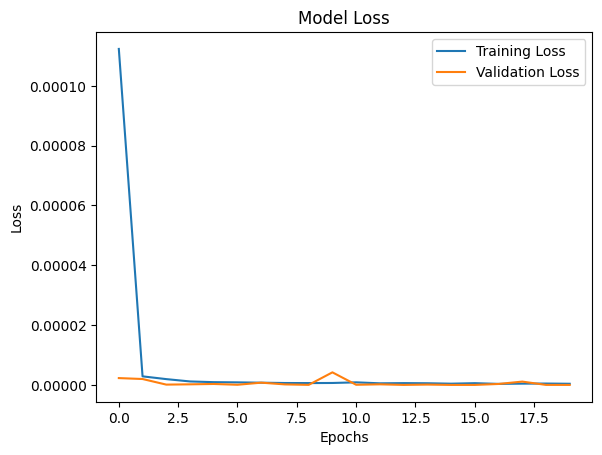

In [25]:
import matplotlib.pyplot as plt

# Plot training & validation loss values
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [26]:
# Evaluate the model on test data
test_loss = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss}")


1800/1800 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 4.2771e-09
Test Loss: 4.3153893791725295e-09


In [27]:
# Make predictions on test data
predictions = model.predict(X_test[:5])  # Predict first 5 samples
print(predictions)
print(y_test[:5])  # Compare with actual values


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 274ms/step
[[0.4670202 ]
 [0.522504  ]
 [0.48231012]
 [0.47018623]
 [0.4736309 ]]
[0.46704078 0.52243272 0.48231747 0.47020359 0.47364628]


In [39]:
model.save("seismic_ai_model.h5")
print("Model saved successfully!")


Model saved successfully!


In [40]:
from google.colab import files
files.download("seismic_ai_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [42]:
from tensorflow.keras.models import load_model

# Load the trained model
model = load_model("seismic_ai_model.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [8]:
from datetime import datetime, timedelta

# Get current UTC time and subtract 10 minutes
end_time = datetime.utcnow()
start_time = end_time - timedelta(minutes=10)

params = {
    "net": "IU",  # Global seismic network
    "sta": "ANMO",  # Station code
    "loc": "--",  # Default location
    "cha": "BHZ",  # Vertical seismic movement
    "start": start_time.strftime("%Y-%m-%dT%H:%M:%S"),
    "end": end_time.strftime("%Y-%m-%dT%H:%M:%S")
}


# New Section

In [9]:
iris_url = "https://service.iris.edu/fdsnws/dataselect/1/query"

params = {
    "net": "IU",        # Global seismic network (change if needed)
    "sta": "ANMO",      # Change to another active station if needed
    "loc": "00",        # Use '00' or '--' for default
    "cha": "BHZ",       # Vertical seismic movement
    "start": "2024-03-16T00:00:00",  # Adjust to recent UTC time
    "end": "2024-03-16T00:10:00"     # 10 minutes of data
}

response = requests.get(iris_url, params=params)

if response.status_code == 200 and response.content:
    with open("real_time_seismic_api_data.mseed", "wb") as f:
        f.write(response.content)
    print("✅ Seismic data downloaded successfully!")
else:
    print("❌ Failed to fetch data. Status code:", response.status_code)
    print("Response content:", response.text)  # Debugging


NameError: name 'requests' is not defined

In [10]:
import os
print("File exists:", os.path.exists("real_time_seismic_api_data.mseed"))


File exists: False


In [11]:
import obspy

# Load the MiniSEED file to verify its contents
seismic_data = obspy.read("real_time_seismic_api_data.mseed")
print(seismic_data)


FileNotFoundError: [Errno 2] No such file or directory: 'real_time_seismic_api_data.mseed'

In [12]:
import numpy as np

# Convert seismic waveform into numpy array
seismic_array = np.array([tr.data for tr in seismic_data])

# Normalize the data (if required)
seismic_array = seismic_array / np.max(np.abs(seismic_array))

# Reshape if needed (e.g., if the model expects specific input shape)
seismic_array = seismic_array.reshape((seismic_array.shape[0], seismic_array.shape[1], 1))

print("Seismic data shape:", seismic_array.shape)


NameError: name 'seismic_data' is not defined

In [13]:
from tensorflow.keras.models import load_model

# Load your trained AI model
model = load_model("seismic_ai_model.h5")

# Make predictions
predictions = model.predict(seismic_array)

# Print predictions
print("Model predictions:", predictions)


NameError: name 'seismic_array' is not defined

In [14]:
threshold = 0.5  # Adjust based on your model's accuracy
earthquake_detected = predictions > threshold

if earthquake_detected.any():
    print("⚠️ Possible earthquake detected!")
else:
    print("✅ No earthquake detected.")


NameError: name 'predictions' is not defined

In [3]:
threshold = 0.8  # Adjusted threshold
earthquake_detected = predictions > threshold

if earthquake_detected.any():
    print("⚠️ Possible earthquake detected!")
else:
    print("✅ No earthquake detected.")


NameError: name 'predictions' is not defined

In [15]:
import numpy as np
import scipy.signal as signal
from sklearn.preprocessing import MinMaxScaler

def preprocess_seismic_data(seismic_waveform, lowcut=0.1, highcut=20.0, fs=100, normalize=True):
    """
    Preprocess seismic waveform data.

    - Applies a bandpass filter to remove noise.
    - Normalizes the data for model stability.

    Parameters:
        seismic_waveform (array): Raw seismic signal.
        lowcut (float): Low-frequency cutoff for bandpass filter.
        highcut (float): High-frequency cutoff for bandpass filter.
        fs (int): Sampling frequency (default: 100 Hz).
        normalize (bool): Whether to normalize the data (default: True).

    Returns:
        array: Preprocessed seismic waveform.
    """

    # Design a bandpass filter (Butterworth)
    order = 4  # Filter order
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')

    #


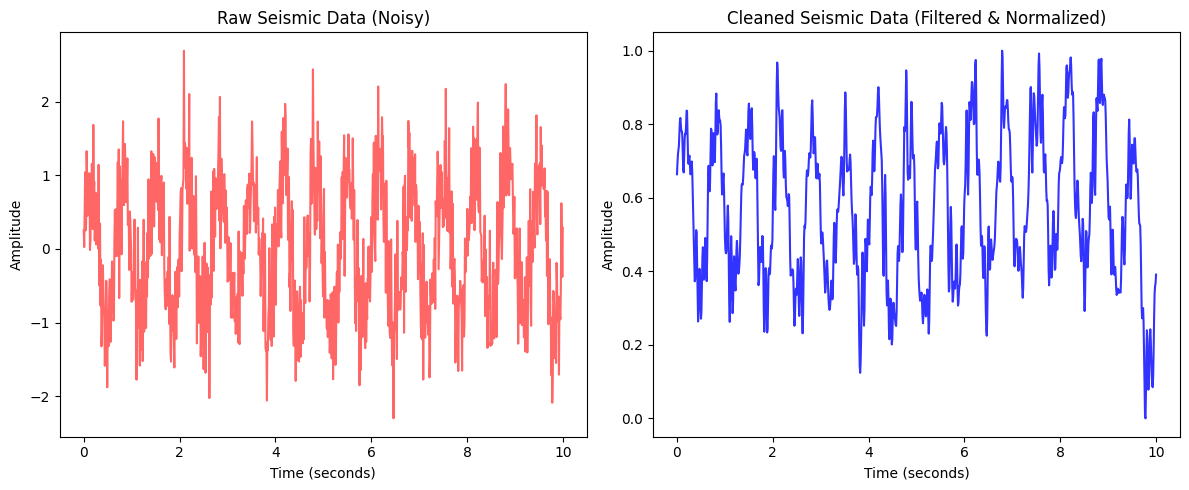

In [16]:
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler

def preprocess_seismic_data(seismic_waveform, lowcut=0.1, highcut=20.0, fs=100, normalize=True):
    """
    Preprocess seismic waveform data.

    - Applies a bandpass filter to remove noise.
    - Normalizes the data for model stability.

    Parameters:
        seismic_waveform (array): Raw seismic signal.
        lowcut (float): Low-frequency cutoff for bandpass filter.
        highcut (float): High-frequency cutoff for bandpass filter.
        fs (int): Sampling frequency (default: 100 Hz).
        normalize (bool): Whether to normalize the data (default: True).

    Returns:
        array: Preprocessed seismic waveform.
    """

    # Design a bandpass filter (Butterworth)
    order = 4  # Filter order
    nyquist = 0.5 * fs  # Nyquist frequency
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = signal.butter(order, [low, high], btype='band')

    # Apply the filter
    filtered_signal = signal.filtfilt(b, a, seismic_waveform)

    # Normalize data (optional)
    if normalize:
        scaler = MinMaxScaler(feature_range=(0, 1))
        filtered_signal = scaler.fit_transform(filtered_signal.reshape(-1, 1)).flatten()

    return filtered_signal

# Generate a synthetic noisy seismic waveform (Replace this with real data)
np.random.seed(42)
time = np.linspace(0, 10, 1000)  # 10 seconds of data, 100 Hz sampling rate
raw_seismic_data = np.sin(2 * np.pi * 1.5 * time) + np.random.normal(0, 0.5, len(time))  # Simulated waveform

# Apply preprocessing
cleaned_seismic_data = preprocess_seismic_data(raw_seismic_data)

# Plot the results
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(time, raw_seismic_data, color='red', alpha=0.6)
plt.title("Raw Seismic Data (Noisy)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.subplot(1, 2, 2)
plt.plot(time, cleaned_seismic_data, color='blue', alpha=0.8)
plt.title("Cleaned Seismic Data (Filtered & Normalized)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.tight_layout()
plt.show()


In [57]:
# Reshape data for model input
seismic_array = cleaned_seismic_data.reshape(1, -1)

# Make predictions
predictions = model.predict(seismic_array)

# Set a threshold for earthquake detection
threshold = 0.8  # Adjust as needed
earthquake_detected = predictions > threshold

# Display results
if earthquake_detected.any():
    print("⚠️ Possible earthquake detected!")
else:
    print("✅ No earthquake detected.")


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

In [58]:
# Ensure the array is properly shaped for model input
seismic_array = cleaned_seismic_data.reshape(1, -1)  # Ensure it's a 2D array

# Convert to NumPy float32 (some models require this)
seismic_array = np.array(seismic_array, dtype=np.float32)

# Make predictions
predictions = model.predict(seismic_array)

# Set a threshold for earthquake detection
threshold = 0.8  # Adjust as needed
earthquake_detected = predictions > threshold

# Display results
if earthquake_detected.any():
    print("⚠️ Possible earthquake detected!")
else:
    print("✅ No earthquake detected.")


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

In [59]:
print("Expected model input shape:", model.input_shape)
print("Shape of seismic_array:", seismic_array.shape)


Expected model input shape: (None, 100, 1)
Shape of seismic_array: (1, 1000)


In [61]:
print("Model expected input shape:", model.input_shape)
print("Seismic array shape:", seismic_array.shape)
print("Seismic array type:", type(seismic_array))


Model expected input shape: (None, 100, 1)
Seismic array shape: (1, 1000)
Seismic array type: <class 'numpy.ndarray'>


In [18]:
import numpy as np

seismic_array = np.array(seismic_array, dtype=np.float32)


NameError: name 'seismic_array' is not defined

In [17]:
print("Seismic array shape:", seismic_array.shape)


NameError: name 'seismic_array' is not defined

In [67]:
seismic_array = seismic_array.reshape(1, 1000, 1)  # 1 batch, 1000 time steps, 1 feature per step


In [68]:
seismic_array = seismic_array.reshape(1, 1000)  # 1 batch, 1000 features


In [69]:
predictions = model.predict(seismic_array)
threshold = 0.8
earthquake_detected = predictions > threshold

if earthquake_detected.any():
    print("⚠️ Possible earthquake detected!")
else:
    print("✅ No earthquake detected.")


ValueError: Exception encountered when calling Sequential.call().

[1mCannot take the length of shape with unknown rank.[0m

Arguments received by Sequential.call():
  • inputs=tf.Tensor(shape=<unknown>, dtype=float32)
  • training=False
  • mask=None

In [70]:
print("Model expected input shape:", model.input_shape)
print("Seismic array shape:", seismic_array.shape)


Model expected input shape: (None, 100, 1)
Seismic array shape: (1, 1000)


In [71]:
import numpy as np

# Reshape seismic array correctly
seismic_array = seismic_array.reshape(-1, 100, 1)  # Ensure (batch_size, 100, 1)

print("Fixed Seismic array shape:", seismic_array.shape)

# Run prediction
predictions = model.predict(seismic_array)
threshold = 0.8
earthquake_detected = predictions > threshold

if earthquake_detected.any():
    print("⚠️ Possible earthquake detected!")
else:
    print("✅ No earthquake detected.")


Fixed Seismic array shape: (10, 100, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
✅ No earthquake detected.


In [76]:
import requests

url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&starttime=2025-01-01"
response = requests.get(url)
data = response.json()

for event in data["features"][:5]:  # Print first 5 events
    print(f"Magnitude: {event['properties']['mag']}, Location: {event['properties']['place']}")


JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [19]:
import requests

url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson"
response = requests.get(url)

print(response.status_code)
print(response.text)  # Check what you're getting back

if response.status_code == 200:
    data = response.json()
    for event in data["features"][:5]:
        print(f"Magnitude: {event['properties']['mag']}, Location: {event['properties']['place']}")
else:
    print("Failed to get data from API.")


Streaming output truncated to the last 5000 lines.
{"type":"Feature","properties":{"mag":1.9,"place":"13 km NNW of Fishhook, Alaska","time":1740645653027,"updated":1740645758192,"tz":null,"url":"https://earthquake.usgs.gov/earthquakes/eventpage/ak0252o26a7q","detail":"https://earthquake.usgs.gov/fdsnws/event/1/query?eventid=ak0252o26a7q&format=geojson","felt":null,"cdi":null,"mmi":null,"alert":null,"status":"automatic","tsunami":0,"sig":56,"net":"ak","code":"0252o26a7q","ids":",ak0252o26a7q,","sources":",ak,","types":",origin,phase-data,","nst":null,"dmin":null,"rms":0.78,"gap":null,"magType":"ml","type":"earthquake","title":"M 1.9 - 13 km NNW of Fishhook, Alaska"},"geometry":{"type":"Point","coordinates":[-149.3277,61.86,2.9]},"id":"ak0252o26a7q"},
{"type":"Feature","properties":{"mag":2.27,"place":"11 km SE of Lares, Puerto Rico","time":1740645501010,"updated":1740646318440,"tz":null,"url":"https://earthquake.usgs.gov/earthquakes/eventpage/pr71473793","detail":"https://earthquake.usg

In [20]:
import requests

url = "https://earthquake.usgs.gov/fdsnws/event/1/query?format=geojson&limit=10"  # Add other filters if needed
response = requests.get(url)

if response.status_code == 200:
    data = response.json()
    input_data = []

    for event in data["features"]:
        props = event["properties"]
        geom = event["geometry"]

        input_data.append({
            "magnitude": props["mag"],
            "depth": geom["coordinates"][2],  # Assuming z-axis is depth
            "latitude": geom["coordinates"][1],
            "longitude": geom["coordinates"][0],
            "place": props["place"],
            "time": props["time"]
        })
else:
    print("API fetch failed.")


In [21]:
import pandas as pd

df = pd.DataFrame(input_data)
X = df[["magnitude", "depth", "latitude", "longitude"]]  # Only pass required features



In [22]:
# Assuming your model is already loaded
predictions = model.predict(X)

# Attach predictions back to original records
for i, pred in enumerate(predictions):
    label = "Earthquake Detected" if pred == 1 else "No Seismic Activity"
    print(f"{input_data[i]['place']} → Prediction: {label}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step
25 km W of Volcano, Hawaii → Prediction: No Seismic Activity
8 km E of Healdsburg, CA → Prediction: No Seismic Activity
10 km NNE of Coso Junction, CA → Prediction: No Seismic Activity
13 km SW of Searles Valley, CA → Prediction: No Seismic Activity
81 km E of Denali Park, Alaska → Prediction: No Seismic Activity
1 km S of Houston, Alaska → Prediction: No Seismic Activity
13 km NNE of Brooktrails, CA → Prediction: No Seismic Activity
south of the Fiji Islands → Prediction: No Seismic Activity
14 km SSW of Tres Pinos, CA → Prediction: No Seismic Activity
32 km WSW of Ackerly, Texas → Prediction: No Seismic Activity
